MNIST dataset contains 28x28 hand-written digits. Please extract 5x5 patches from 28x28 images, and there are more than 20 million such image patches. Of course, a majority of these image patches will be blank. You can discard these blank patches and focus on the rest ones, and do a K-mean clustering with these small image patches.

Please analyze the change of the learned clusters when you increase K from 100 – 10,000 (or even more). You can also analyze how well you can reconstruct a 5x5 MNIST patch by your learned dictionary (clusters). There are some interesting questions: 1) How many clusters do you need in order to cover the whole patch space? What are these clusters and do they have any interpretable meanings? How is one digit made from these clusters? These questions are just some example questions, and you are in charge of what is interesting to you in this weird image patch space.

One useful trick in this experiment may be that you can normalize your patch vector to unit norm, then your clusters can also be normalized, and the Euclidean distance is equivalent to sqrt(2-2<feature vector, image patch vector>). Of course, this will create issue with all blank patch, which needs additional care.



In [21]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.preprocessing import normalize
from sklearn.cluster import MiniBatchKMeans

In [22]:
dataset = torchvision.datasets.MNIST(
    root='./data',         
    download=True
)

In [23]:
def patchify(imgs: torch.Tensor, patch=5, stride=1):
    #input: (B, C, H, W)
    cols = F.unfold(imgs, kernel_size=patch, stride=stride).transpose(1, 2)
    # out: (B, L, 25)  L = number of patches per image
    # Merge (B, L)
    patches = cols.reshape(-1, 25)
    return patches

In [5]:
images = dataset.data.float() / 255.0
images = images.unsqueeze(1)
patches=patchify(images)

#keep only images with non-zero values
non_blank = patches[patches.sum(dim=1) > 0]
print("before norm: ",non_blank[0])
print(non_blank.shape)
patch_vectors = normalize(non_blank, norm='l2')
print("after norm: ", patch_vectors[0])
print(patch_vectors.shape)

before norm:  tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0118])
torch.Size([20074704, 25])
after norm:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1.]
(20074704, 25)


In [57]:
from joblib import dump
import os 

from sklearn.cluster import MiniBatchKMeans
Ks = [10, 25, 50, 75, 100, 200, 300, 400, 500, 750, 1000, 5000, 7500, 10000]
for K in Ks:
    if os.path.exists(f'kmeans_K{K}.pkl'):
        print(f"skipped {K}")
        continue
    
    kmeans = MiniBatchKMeans(
        n_clusters=K,
        random_state=0,
        batch_size=16384,
        max_iter=100,
        n_init="auto",
    ).fit(patch_vectors)

    dump(kmeans, f"kmeans_K{K}.pkl")

skipped 10
skipped 25
skipped 50
skipped 75
skipped 100
skipped 500
skipped 750
skipped 1000
skipped 5000
skipped 7500
skipped 10000


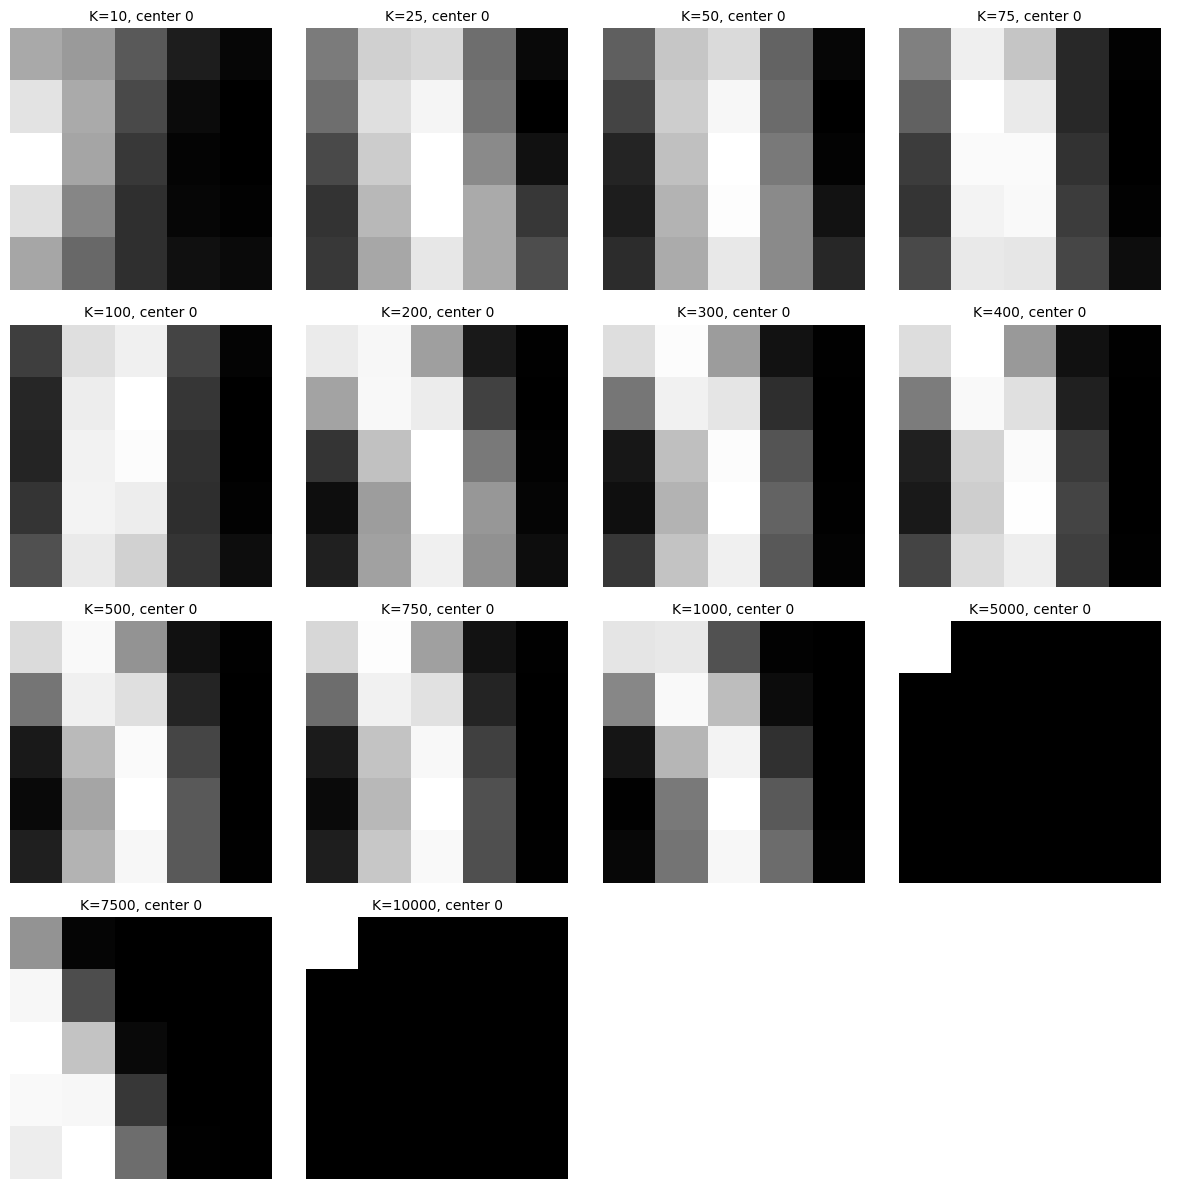

In [58]:
from joblib import load
import numpy as np
import matplotlib.pyplot as plt

j = 0
n = len(Ks)

fig, axs = plt.subplots(4, int(np.ceil(n / 4)), figsize=(12, 12))
axs = axs.ravel()  # make it 1D: [ax0, ax1, ax2, ...]

for i, K in enumerate(Ks):
    ax = axs[i]
    kmeans = load(f"kmeans_K{K}.pkl")
    centers = kmeans.cluster_centers_
    centers_5x5 = centers.reshape(-1, 5, 5)

    ax.imshow(centers_5x5[j], cmap="gray")
    ax.axis("off")
    ax.set_title(f"K={K}, center {j}", fontsize=10)

# Hide any unused slots if Ks is odd
for ax in axs[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


torch.Size([60000, 1, 28, 28])
(28, 28)


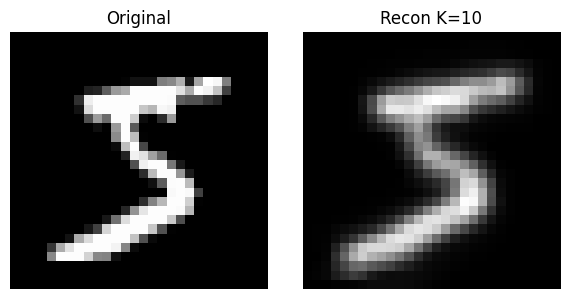

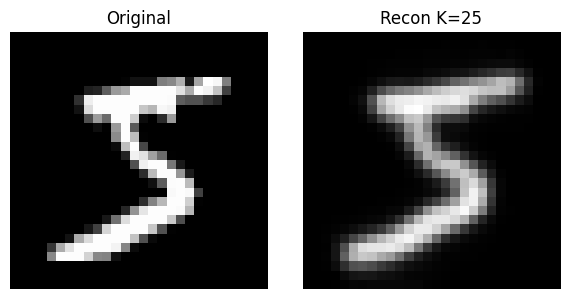

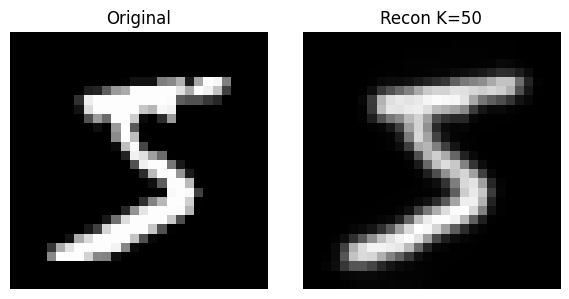

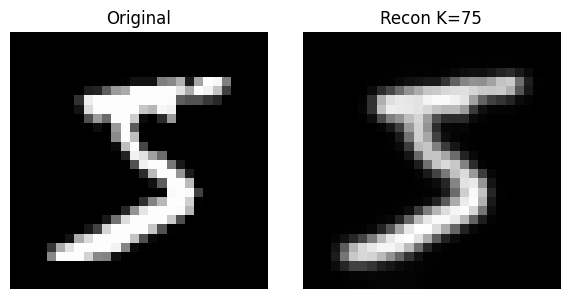

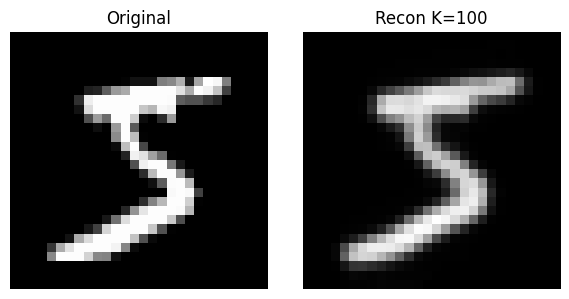

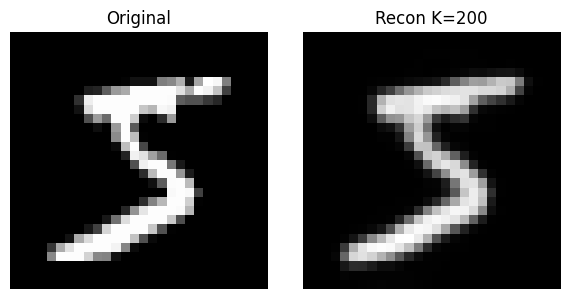

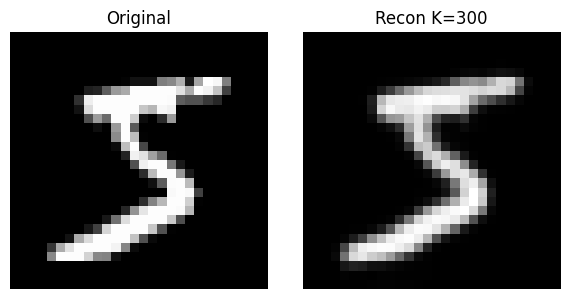

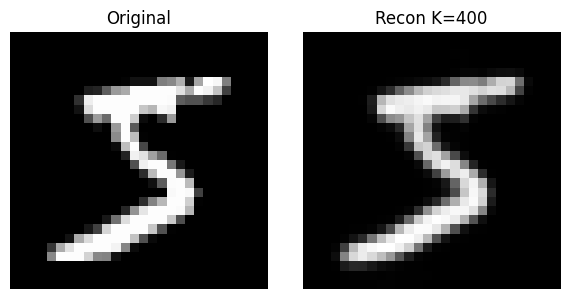

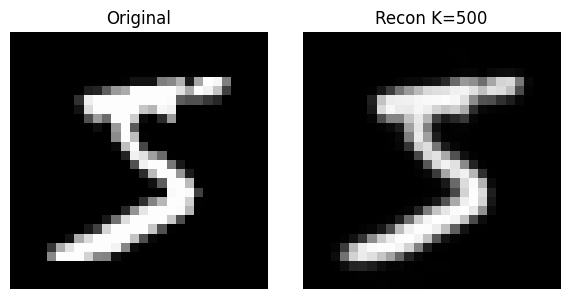

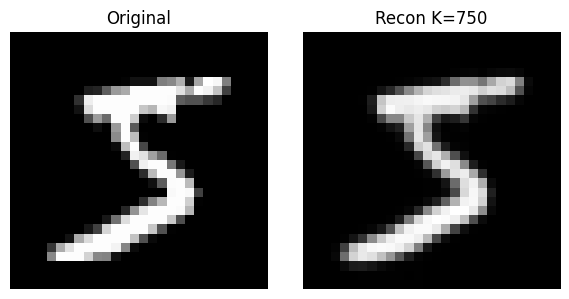

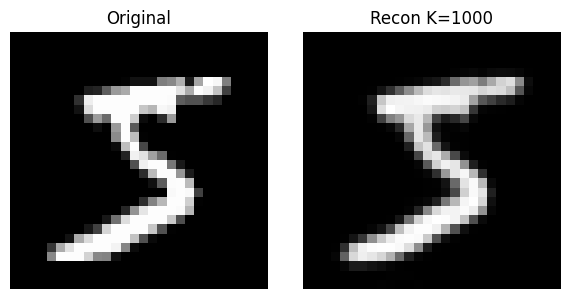

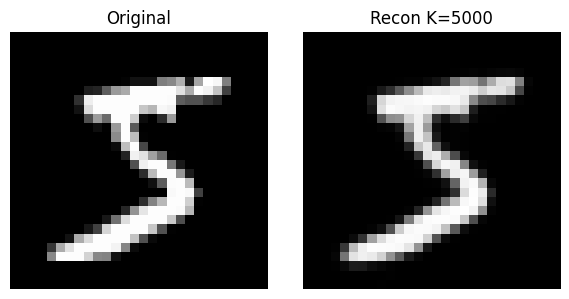

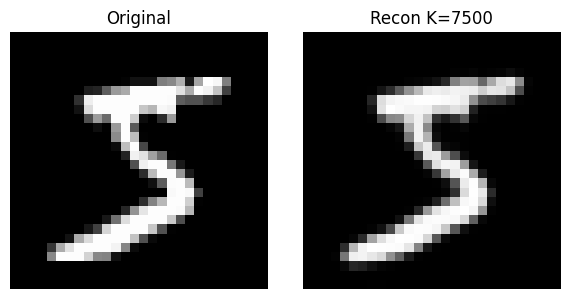

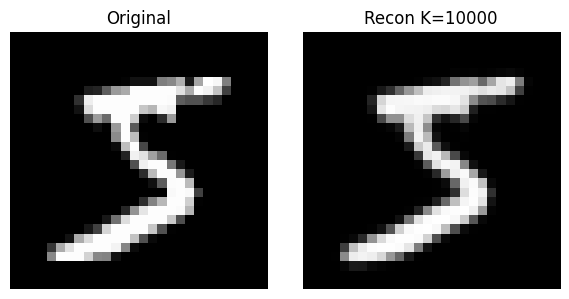

In [59]:
from joblib import load
import numpy as np
import matplotlib.pyplot as plt

print(images.shape)
img28 = images[0].squeeze().numpy().astype(np.float32)
print(img28.shape)

for K in Ks:
    kmeans = load(f"kmeans_K{K}.pkl")

    #extract patches
    X = []
    coords = []
    for r in range(24):
        for c in range(24):
            X.append(img28[r:r+5, c:c+5].reshape(-1))
            coords.append((r, c))
    X = np.stack(X, axis=0)                 

    # L2 normalize
    norms = np.linalg.norm(X, axis=1)
    keep = norms > 0
    Xn = np.zeros_like(X, dtype=np.float32)
    Xn[keep] = X[keep] / norms[keep, None]
    Xn = Xn.astype(kmeans.cluster_centers_.dtype, copy=False)
    labels_keep = kmeans.predict(Xn[keep])
    centers = kmeans.cluster_centers_.astype(np.float32, copy=False)
    Xhat_all = np.zeros((X.shape[0], 25), dtype=np.float32)
    Xhat_all[keep] = centers[labels_keep]

    #un-normalize for visualization
    Xhat_all *= norms[:, None].astype(np.float32)

    acc = np.zeros((28, 28), dtype=np.float32)
    cnt = np.zeros((28, 28), dtype=np.float32)
    for patch, (r, c) in zip(Xhat_all.reshape(-1, 5, 5), coords):
        acc[r:r+5, c:c+5] += patch
        cnt[r:r+5, c:c+5] += 1.0
    #normalize by # overlapping patches
    recon28 = acc / np.maximum(cnt, 1e-8)

    
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(img28, cmap="gray")
    plt.axis("off")
    plt.title("Original")
    plt.subplot(1, 2, 2)
    plt.imshow(recon28, cmap="gray")
    plt.axis("off")
    plt.title(f"Recon K={K}")
    plt.tight_layout()
    plt.show()


In [60]:
from joblib import load
import numpy as np

mses = []

for K in Ks:
    kmeans = load(f'./kmeans_K{K}.pkl')

    labels = kmeans.predict(patch_vectors) 
    centers = kmeans.cluster_centers_
    assigned = centers[labels]
    diffs = assigned - patch_vectors
    mse = np.mean(np.sum(diffs * diffs, axis=1))
    mses.append(mse)

np.save("./mses.npy", np.array(mses, dtype=np.float64))


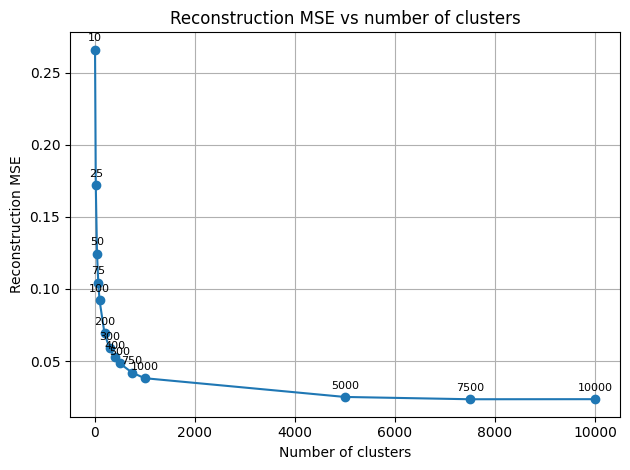

In [76]:
mses = np.load("./mses.npy")

plt.figure()
plt.grid()
plt.title("Reconstruction MSE vs number of clusters")
plt.ylabel("Reconstruction MSE")
plt.xlabel("Number of clusters")

plt.plot(Ks, mses, marker="o")

# Label each point
for K, mse in zip(Ks, mses):
    plt.annotate(
        str(K),
        (K, mse),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
    )

plt.tight_layout()
plt.savefig("elbow.png")
plt.show()


In [74]:
import numpy as np

def centroid_stats(centers, block=2048, eps=1e-8):
    C = centers.astype(np.float32)
    C /= np.linalg.norm(C, axis=1, keepdims=True)

    K = C.shape[0]
    max_cos = np.full(K, -np.inf, dtype=np.float32)

    for i0 in range(0, K, block):
        i1 = min(K, i0 + block)
        S = C[i0:i1] @ C.T #cosine similarity
        np.fill_diagonal(S[:, i0:i1], -np.inf)  #no self-comparison
        max_cos[i0:i1] = S.max(axis=1) #take max cos similiarity

    return max_cos


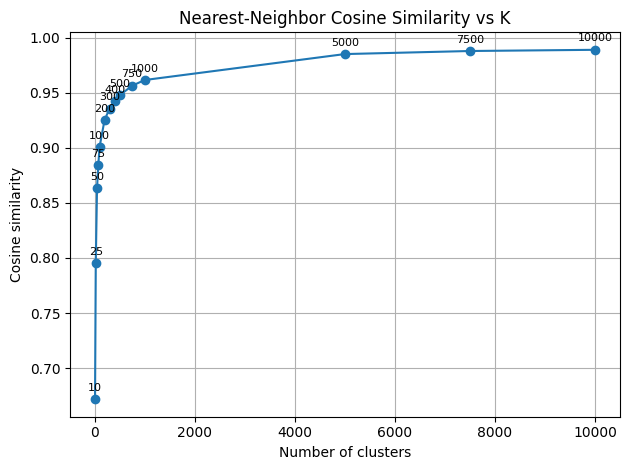

In [78]:
from joblib import load
import numpy as np
import matplotlib.pyplot as plt

avg_cos = []

for K in Ks:
    kmeans = load(f'./kmeans_K{K}.pkl')
    centers = kmeans.cluster_centers_
    nn_cos_max = centroid_stats(centers, block=2048)
    avg_cos.append(np.mean(nn_cos_max))

avg_cos = np.array(avg_cos)

plt.figure()
plt.grid()
plt.title("Nearest-Neighbor Cosine Similarity vs K")
plt.xlabel("Number of clusters")
plt.ylabel("Cosine similarity")

plt.plot(Ks, avg_cos, marker="o", label="Average NN cosine")


for K, a, m in zip(Ks, avg_cos, med_cos):
    plt.annotate(str(K), (K, a), textcoords="offset points", xytext=(0, 6),
                 ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("cos.png")
plt.show()


In [79]:
from joblib import load
import numpy as np
import matplotlib.pyplot as plt

# how many images to evaluate
N_IMG = 100

img_mses = []

for K in Ks:
    kmeans = load(f"kmeans_K{K}.pkl")

    total_mse = 0.0

    for n in range(N_IMG):
        img28 = images[n].squeeze().numpy().astype(np.float32)

        # extract 5x5 patches
        X = []
        coords = []
        for r in range(24):
            for c in range(24):
                X.append(img28[r:r+5, c:c+5].reshape(-1))
                coords.append((r, c))
        X = np.stack(X, axis=0)

        # normalize 
        norms = np.linalg.norm(X, axis=1)
        keep = norms > 0
        Xn = np.zeros_like(X, dtype=np.float32)
        Xn[keep] = X[keep] / norms[keep, None]
        
        Xn = Xn.astype(kmeans.cluster_centers_.dtype, copy=False)
        labels = kmeans.predict(Xn[keep])
        centers = kmeans.cluster_centers_.astype(np.float32, copy=False)

        Xhat = np.zeros_like(X, dtype=np.float32)
        Xhat[keep] = centers[labels]

        # un-normalize for visualization 
        Xhat *= norms[:, None]

        #reassemble
        acc = np.zeros((28, 28), dtype=np.float32)
        cnt = np.zeros((28, 28), dtype=np.float32)
        for patch, (r, c) in zip(Xhat.reshape(-1, 5, 5), coords):
            acc[r:r+5, c:c+5] += patch
            cnt[r:r+5, c:c+5] += 1.0

        recon28 = acc / np.maximum(cnt, 1e-8)

        total_mse += np.mean((img28 - recon28) ** 2)

    avg_img_mse = total_mse / N_IMG
    img_mses.append(avg_img_mse)
    print(f"K={K:>5}  image_MSE={avg_img_mse:.6f}")

img_mses = np.array(img_mses)
np.save("image_mses.npy", img_mses)


K=   10  image_MSE=0.014211
K=   25  image_MSE=0.008538
K=   50  image_MSE=0.005821
K=   75  image_MSE=0.004543
K=  100  image_MSE=0.004000
K=  200  image_MSE=0.002924
K=  300  image_MSE=0.002460
K=  400  image_MSE=0.002157
K=  500  image_MSE=0.001955
K=  750  image_MSE=0.001710
K= 1000  image_MSE=0.001542
K= 5000  image_MSE=0.001021
K= 7500  image_MSE=0.000923
K=10000  image_MSE=0.000845


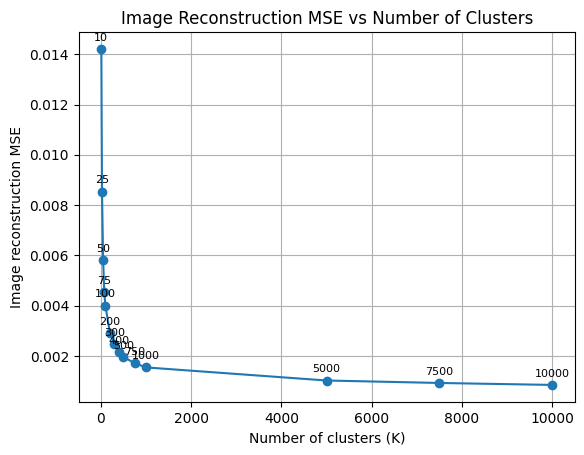

In [83]:
img_mses = np.load("image_mses.npy")

plt.figure()
plt.grid()
plt.title("Image Reconstruction MSE vs Number of Clusters")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Image reconstruction MSE")

plt.plot(Ks, img_mses, marker="o")

for K, mse in zip(Ks, img_mses):
    plt.annotate(str(K), (K, mse), textcoords="offset points",
                 xytext=(0, 6), ha="center", fontsize=8)
plt.savefig("reconstruct.png")
plt.show()
